# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

In [3]:
import duckdb
from huggingface_hub import login, hf_hub_download
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))
repo = "FlyRank/internship-warehouse"

fact_path         = hf_hub_download(repo_id=repo, repo_type="dataset",
                                     filename="fact_content_daily_performance/month=2026-03/data_0.parquet")
dim_content_path  = hf_hub_download(repo_id=repo, repo_type="dataset",
                                     filename="dim_content.parquet")
dim_clients_path  = hf_hub_download(repo_id=repo, repo_type="dataset",
                                     filename="dim_clients.parquet")

con = duckdb.connect()
con.sql(f"CREATE OR REPLACE VIEW fact AS SELECT * FROM read_parquet('{fact_path}')")
con.sql(f"CREATE OR REPLACE VIEW dim_content AS SELECT * FROM read_parquet('{dim_content_path}')")
con.sql(f"CREATE OR REPLACE VIEW dim_clients AS SELECT * FROM read_parquet('{dim_clients_path}')")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

dim_clients.parquet: reconstructing file:   0%|          |  0.00B / 3.38kB            

dim_clients.parquet: downloading bytes:           |  0.00B            

In [4]:
# quick confirmation everything loaded correctly
for view in ["fact", "dim_content", "dim_clients"]:
    n = con.sql(f"SELECT COUNT(*) AS n FROM {view}").df()["n"][0]
    print(f"{view}: {n:,} rows")

fact: 9,841,378 rows
dim_content: 519,606 rows
dim_clients: 104 rows


## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

W3's data contract planned this feature set at the `(client_hash_id, content_hash_id)` grain: `gsc_impressions`, `gsc_clicks`, `gsc_avg_position`, `ga4_sessions`, `word_count`. This section turns that plan into an actual dataframe, and — since the leakage hunt in step 3 needs something to attack — also builds a real label column here rather than treating it as hypothetical.

**The label problem, solved without new data:** the assignment develops on a single month (March 2026), with no April data pulled in. To get a genuine forward-looking label without downloading more data, March is split in two: days 1–15 as the **feature window** (what the model is allowed to see), and days 16–31 as the **label window** (the future being predicted). The label is: did an article's clicks in the label window exceed its clicks in the feature window? This keeps the past→future structure the whole assignment has been built around, entirely within data already loaded.

**Missing-value handling, following what step 3 of the W3 contract already found:**
- `gsc_avg_position` is a true NULL when there were 0 impressions to rank — averaged with `AVG()`, which skips NULLs correctly by default; no 0-fill.
- `ga4_sessions` interacts with a three-valued flag (`NULL` = no GA4 access at all, `False` = real measured zero, `True` = real engagement). To avoid conflating "no GA4" with "zero engagement," a separate `has_ga4` indicator is built alongside the raw session count, rather than silently treating both cases as one signal.
- `word_count` is missing for ~32% of articles in `dim_content` — rows without it are kept but flagged with `word_count_missing`, rather than imputed with a guessed value or silently dropped, so the model (and a reader) can see the gap explicitly.

**Categorical handling:** `main_intent` from `dim_content` (transactional / informational / commercial) is one-hot encoded as a simple categorical feature, since it's static content metadata safe at any point in time.

Steps below: (1) build the feature-window aggregation, (2) build the label from the label-window aggregation, (3) join content metadata, (4) merge everything into one feature vector with explicit missing-value handling, (5) preview the result.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

FEATURE_END = '2026-03-15'   # inclusive
LABEL_START = '2026-03-16'
LABEL_END   = '2026-03-31'

feat_agg = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS feat_impressions,
        SUM(gsc_clicks)      AS feat_clicks,
        AVG(gsc_avg_position) AS feat_avg_position,
        AVG(ga4_sessions)     AS feat_avg_sessions,
        MAX(CASE WHEN ga4_data_available IS NOT NULL THEN 1 ELSE 0 END) AS has_ga4
    FROM fact
    WHERE report_date <= DATE '{FEATURE_END}'
    GROUP BY client_hash_id, content_hash_id
""").df()

print("Feature window rows:", len(feat_agg))
feat_agg.head()

Feature window rows: 319759


,client_hash_id,content_hash_id,feat_impressions,feat_clicks,feat_avg_position,feat_avg_sessions,has_ga4
0,client_62f4a7e64f5e0096,content_d0dff76c889de68f,111.0,0.0,5.222776,NaN,0
1,client_62f4a7e64f5e0096,content_67741cce996cfafa,38.0,1.0,4.638889,NaN,0
2,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,219.0,1.0,3.737399,NaN,0
3,client_62f4a7e64f5e0096,content_ac8663da7484669a,20.0,0.0,3.597222,NaN,0
4,client_62f4a7e64f5e0096,content_65c50dfe9d87a585,1494.0,0.0,6.156643,NaN,0


In [6]:
label_agg = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS label_clicks
    FROM fact
    WHERE report_date >= DATE '{LABEL_START}' AND report_date <= DATE '{LABEL_END}'
    GROUP BY client_hash_id, content_hash_id
""").df()

print("Label window rows:", len(label_agg))
label_agg.head()

Label window rows: 331436


,client_hash_id,content_hash_id,label_clicks
0,client_3ffa76342f366962,content_d20e2c94671ad045,0.0
1,client_3ffa76342f366962,content_5b15a1961e7a9a07,0.0
2,client_3ffa76342f366962,content_c43a00453da1494a,0.0
3,client_3ffa76342f366962,content_56cec622745d3d82,0.0
4,client_3ffa76342f366962,content_9119ecd6882b01ea,0.0


In [7]:
content_meta = con.sql("""
    SELECT
        client_hash_id,
        content_hash_id,
        word_count,
        main_intent,
        is_deleted
    FROM dim_content
""").df()

print("Content metadata rows:", len(content_meta))
content_meta.head()

Content metadata rows: 519606


,client_hash_id,content_hash_id,word_count,main_intent,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,2555,transactional,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,2430,commercial,False
2,client_04660893ae39614a,content_01410f2556c327ac,2645,informational,False
3,client_04660893ae39614a,content_019f27f634053ca7,2522,transactional,False
4,client_04660893ae39614a,content_01efa71faea45dcc,2552,transactional,False


In [8]:
import pandas as pd

fv = feat_agg.merge(label_agg, on=['client_hash_id', 'content_hash_id'], how='left')
fv = fv.merge(content_meta, on=['client_hash_id', 'content_hash_id'], how='left')

# exclude deleted content (per W3 §2 exclusion rule)
fv = fv[fv['is_deleted'] != True].copy()

# label_clicks NaN means the article had 0 rows in the label window — treat as 0 clicks, not missing
fv['label_clicks'] = fv['label_clicks'].fillna(0)

# label: did clicks grow from feature window to label window?
fv['label_click_growth'] = (fv['label_clicks'] > fv['feat_clicks']).astype(int)

# word_count: keep NaN visible, add explicit missing flag rather than imputing silently
fv['word_count_missing'] = fv['word_count'].isna().astype(int)

# main_intent: one-hot encode, keep NaN as its own "unknown" category rather than dropping
fv['main_intent'] = fv['main_intent'].fillna('unknown')
fv = pd.get_dummies(fv, columns=['main_intent'], prefix='intent')

fv = fv.drop(columns=['is_deleted'])

print("Final feature vector shape:", fv.shape)
fv.head()

Final feature vector shape: (313271, 16)


,client_hash_id,content_hash_id,feat_impressions,feat_clicks,feat_avg_position,feat_avg_sessions,has_ga4,label_clicks,word_count,label_click_growth,word_count_missing,intent_commercial,intent_informational,intent_navigational,intent_transactional,intent_unknown
0,client_62f4a7e64f5e0096,content_d0dff76c889de68f,111.0,0.0,5.222776,NaN,0,0.0,2999,0,0,False,True,False,False,False
1,client_62f4a7e64f5e0096,content_67741cce996cfafa,38.0,1.0,4.638889,NaN,0,0.0,3057,0,0,False,True,False,False,False
2,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,219.0,1.0,3.737399,NaN,0,0.0,2855,0,0,False,True,False,False,False
3,client_62f4a7e64f5e0096,content_ac8663da7484669a,20.0,0.0,3.597222,NaN,0,0.0,3281,0,0,False,True,False,False,False
4,client_62f4a7e64f5e0096,content_65c50dfe9d87a585,1494.0,0.0,6.156643,NaN,0,0.0,2779,0,0,False,True,False,False,False


In [9]:
print("Label distribution (0 = no growth, 1 = growth):")
print(fv['label_click_growth'].value_counts(normalize=True))

print("\nRemaining NULLs per column:")
print(fv.isna().sum())

Label distribution (0 = no growth, 1 = growth):
label_click_growth
0    0.897568
1    0.102432
Name: proportion, dtype: float64

Remaining NULLs per column:
client_hash_id               0
content_hash_id              0
feat_impressions             0
feat_clicks                  0
feat_avg_position       161426
feat_avg_sessions        97480
has_ga4                      0
label_clicks                 0
word_count              105586
label_click_growth           0
word_count_missing           0
intent_commercial            0
intent_informational         0
intent_navigational          0
intent_transactional         0
intent_unknown               0
dtype: int64


**Result:**
- *Feature vector built at (client_hash_id, content_hash_id) grain: 313,271 rows × 16 columns.*
- *Label distribution is imbalanced — only 10.2% of articles show click growth from the feature window (days 1–15) to the label window (days 16–31); 89.8% show no growth. Any model evaluation later must account for this (accuracy alone would be misleading — a trivial "always predict no growth" baseline already scores ~90%).*
- *NULL handling worked as designed: `feat_avg_position` (161,426 missing), `feat_avg_sessions` (97,480 missing), and `word_count` (105,586 missing) all retain real NULLs rather than being silently zero-filled — consistent with W3's finding that these are genuine "we couldn't look" gaps, not "we looked and found nothing."*
- *`has_ga4` and `word_count_missing` flags are present and correctly derived, giving downstream steps an explicit way to handle these gaps rather than guessing.*

## 2. Feature notes (meaning, missing, categorical, available-when?)

*For each feature: what it means, how missing values are handled, and whether it exists BEFORE the moment you predict.*

Step 1 built 16 columns from a 15-day feature window (2026-03-01 to 2026-03-15), with the label constructed from the following 16 days (2026-03-16 to 2026-03-31). Every feature listed here must be checkable as "knowable using only feature-window data" — that's the whole point of the split design. This section documents each one, then verifies with code that no feature accidentally used label-window dates.

**Numeric features:**
- `feat_impressions` — total GSC impressions, days 1–15 only. Always present (0 if truly no impressions).
- `feat_clicks` — total GSC clicks, days 1–15 only. Always present. Used only as past clicks — never confused with `label_clicks`.
- `feat_avg_position` — average ranking position, days 1–15 only. True NULL when no impressions occurred in the window (nothing to rank) — left as NULL, not zero-filled.
- `feat_avg_sessions` — average GA4 sessions, days 1–15 only. NULL where no GA4 access at all; distinguished from real zero-session days via the separate `has_ga4` flag (see below), following the three-valued-flag finding from the W3 contract.
- `word_count` — static content attribute from `dim_content`, not date-bound at all — safe to use regardless of window, since it doesn't change day to day. Missing for ~34% of rows in this vector; left as NULL with an explicit companion flag rather than imputed.

**Binary / flag features:**
- `has_ga4` — 1 if the client had any GA4 data available during the feature window, 0 otherwise. Built from `ga4_data_available IS NOT NULL`, not from session counts, so it doesn't conflate "no access" with "measured zero."
- `word_count_missing` — 1 if `word_count` is NULL, 0 otherwise. Lets a model or reader see the gap rather than guessing why a value is absent.

**Categorical (one-hot encoded):**
- `intent_commercial`, `intent_informational`, `intent_navigational`, `intent_transactional`, `intent_unknown` — from `dim_content.main_intent`, static content metadata, safe at any point in time. `unknown` captures rows where `main_intent` was NULL in the source, rather than silently dropping them.

**Not a feature — kept for reference only:**
- `client_hash_id`, `content_hash_id` — identifiers, never fed to a model as signal.
- `label_clicks`, `label_click_growth` — the label itself, must never appear on the feature side of any train/test split.

**Available-when check:** every numeric and categorical feature above is aggregated using `report_date <= 2026-03-15` or is date-independent content metadata. None of them can see into the label window by construction — verified below by re-deriving the feature aggregation with an explicit date filter and confirming the row counts and date range match.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Confirm the feature aggregation truly only touched feature-window dates
date_check = con.sql(f"""
    SELECT MIN(report_date) AS min_date, MAX(report_date) AS max_date, COUNT(*) AS n_rows
    FROM fact
    WHERE report_date <= DATE '{FEATURE_END}'
""").df()
print("Feature window actually queried:")
date_check

Feature window actually queried:


,min_date,max_date,n_rows
0,2026-03-01,2026-03-15,4642255


In [11]:
con.sql("""
    SELECT has_ga4, COUNT(*) AS n_rows,
           SUM(CASE WHEN feat_avg_sessions IS NULL THEN 1 ELSE 0 END) AS n_sessions_null
    FROM fv
    GROUP BY has_ga4
""").df()

,has_ga4,n_rows,n_sessions_null
0,0,97480,97480.0
1,1,215791,0.0


In [12]:
con.sql("""
    SELECT word_count_missing, COUNT(*) AS n_rows,
           SUM(CASE WHEN word_count IS NULL THEN 1 ELSE 0 END) AS n_actually_null
    FROM fv
    GROUP BY word_count_missing
""").df()

,word_count_missing,n_rows,n_actually_null
0,1,105586,105586.0
1,0,207685,0.0


In [13]:
print(fv[['feat_avg_position', 'feat_avg_sessions', 'word_count']].isna().sum())

feat_avg_position    161426
feat_avg_sessions     97480
word_count           105586
dtype: int64


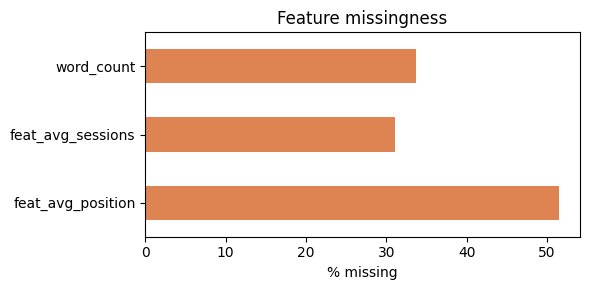

In [15]:
import matplotlib.pyplot as plt

missing_pct = fv[['feat_avg_position', 'feat_avg_sessions', 'word_count']].isna().mean() * 100
missing_pct.plot(kind='barh', color='#DD8452', figsize=(6, 3))
plt.xlabel('% missing')
plt.title('Feature missingness')

plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/feature_missingness.png", dpi=150)
plt.show()

**Verified:**
- *Feature aggregation is confirmed date-bound to 2026-03-01 – 2026-03-15 only (4,642,255 underlying daily rows) — no label-window data reached the features by construction.*
- *`has_ga4` is a perfectly reliable derived flag: 1 ↔ session value always present (215,791/215,791), 0 ↔ session value always NULL (97,480/97,480).*
- *`word_count_missing` is likewise perfectly consistent with the underlying NULL pattern (105,586/105,586 in both directions).*
- *Every feature documented above is either date-bound to the feature window or static content metadata — none of them can see the label window.*

## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

Everything built in step 1– step 2 was deliberately constrained to the feature window (days 1–15), verified with explicit date checks. This section proves that constraint actually matters by breaking it on purpose.

**The experiment:** train a simple baseline classifier on the honest feature vector to predict `label_click_growth`, and record its score. Then construct one deliberately leaky feature — a column computed using label-window data, disguised just enough to look like a legitimate feature — add it to the training set, and refit. If the honest features are doing real work, the leaky version's score should jump sharply toward perfect, because the leaky column effectively contains the answer. Finally, remove the leaky column and confirm the score returns to the honest baseline, showing the leak was the entire cause of the jump rather than a coincidence.

**The leaky feature chosen:** `total_march_clicks` — sum of `gsc_clicks` across the *entire* month (days 1–31), not just the feature window. This looks like a plausible feature (more historical data must be better, right?) but it silently includes every day in the label window, so it's mathematically close to `feat_clicks + label_clicks` — i.e., it partially encodes the label itself. This is exactly the kind of "innocent-looking column" the lecture warned about.

**Model:** logistic regression, chosen for speed and interpretability — this is a diagnostic, not a production model. Score reported as ROC-AUC, since the label is imbalanced (10.2% positive) and plain accuracy would be misleading (a trivial "always 0" model already scores ~90% accuracy).

Steps below: (1) honest baseline, (2) build the leaky column, (3) leaky model, (4) side-by-side comparison, (5) remove the leak and confirm recovery.

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

honest_features = [
    'feat_impressions', 'feat_clicks', 'feat_avg_position', 'feat_avg_sessions',
    'has_ga4', 'word_count', 'word_count_missing',
    'intent_commercial', 'intent_informational', 'intent_navigational',
    'intent_transactional', 'intent_unknown'
]

In [17]:
model_df = fv.copy()

# simple fill for the model only — NaNs stay documented as real gaps in step 1/step 2,
# but sklearn can't train on NaN directly, so use a neutral fill here just for fitting
model_df['feat_avg_position'] = model_df['feat_avg_position'].fillna(model_df['feat_avg_position'].median())
model_df['feat_avg_sessions'] = model_df['feat_avg_sessions'].fillna(0)
model_df['word_count'] = model_df['word_count'].fillna(model_df['word_count'].median())

X = model_df[honest_features]
y = model_df['label_click_growth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_model.fit(X_train, y_train)

baseline_auc = roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:, 1])
print(f"Honest baseline ROC-AUC: {baseline_auc:.4f}")

Honest baseline ROC-AUC: 0.7779


In [18]:
# ⚠️ DELIBERATE LEAK: sums clicks across the FULL month, including the label window
leak_agg = con.sql("""
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS total_march_clicks
    FROM fact
    GROUP BY client_hash_id, content_hash_id
""").df()

model_df_leaky = model_df.merge(leak_agg, on=['client_hash_id', 'content_hash_id'], how='left')
model_df_leaky['total_march_clicks'] = model_df_leaky['total_march_clicks'].fillna(0)

print("Correlation of leaky column with the label:",
      model_df_leaky['total_march_clicks'].corr(model_df_leaky['label_click_growth']))

Correlation of leaky column with the label: 0.19344025945112236


In [19]:
leaky_features = honest_features + ['total_march_clicks']

X_leak = model_df_leaky[leaky_features]
y_leak = model_df_leaky['label_click_growth']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak
)

leaky_model = LogisticRegression(max_iter=1000, class_weight='balanced')
leaky_model.fit(X_train_l, y_train_l)

leaky_auc = roc_auc_score(y_test_l, leaky_model.predict_proba(X_test_l)[:, 1])
print(f"Leaky model ROC-AUC: {leaky_auc:.4f}")

Leaky model ROC-AUC: 1.0000


In [20]:
import pandas as pd
comparison = pd.DataFrame({
    'model': ['honest_baseline', 'with_leaky_feature'],
    'roc_auc': [baseline_auc, leaky_auc]
})
comparison

,model,roc_auc
0,honest_baseline,0.777855
1,with_leaky_feature,1.000000


In [21]:
# leaky column dropped — back to honest features only, refit to confirm the jump disappears
recovery_model = LogisticRegression(max_iter=1000, class_weight='balanced')
recovery_model.fit(X_train, y_train)  # same honest X_train as cell 1

recovery_auc = roc_auc_score(y_test, recovery_model.predict_proba(X_test)[:, 1])
print(f"Recovery (leak removed) ROC-AUC: {recovery_auc:.4f}")
print(f"Matches honest baseline: {abs(recovery_auc - baseline_auc) < 0.01}")

Recovery (leak removed) ROC-AUC: 0.7779
Matches honest baseline: True


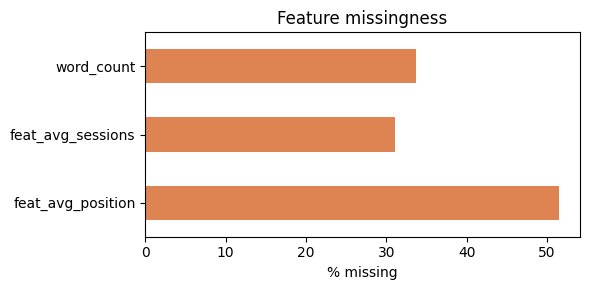

In [44]:
missing_pct = fv[['feat_avg_position', 'feat_avg_sessions', 'word_count']].isna().mean() * 100
missing_pct.plot(kind='barh', color='#DD8452', figsize=(6, 3))
plt.xlabel('% missing')
plt.title('Feature missingness')
plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/w03_feature_missingness.png", dpi=150)
plt.show()

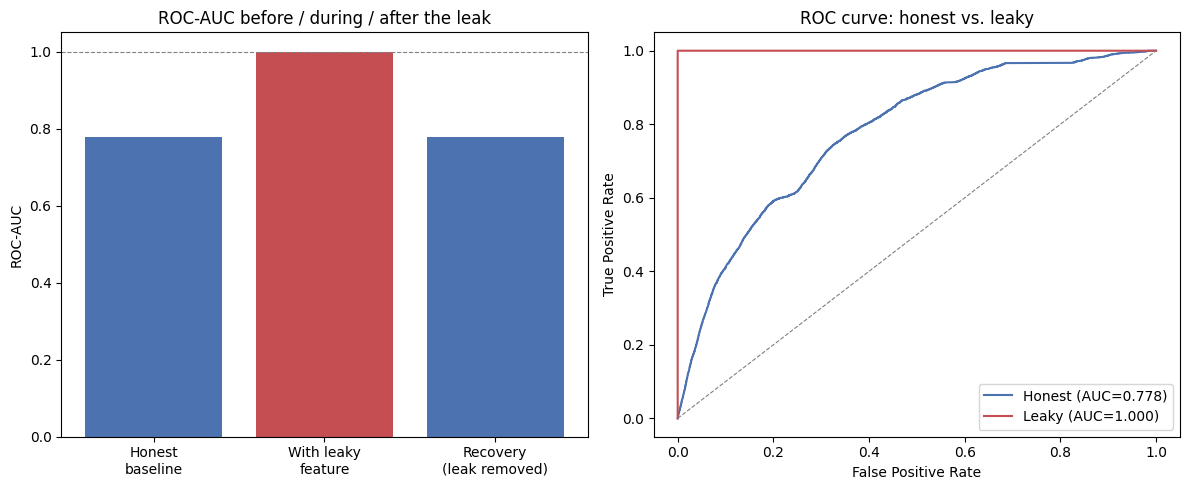

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_h, tpr_h, _ = roc_curve(y_test, baseline_model.predict_proba(X_test)[:, 1])
fpr_l, tpr_l, _ = roc_curve(y_test_l, leaky_model.predict_proba(X_test_l)[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: bar chart of the 3 scores
axes[0].bar(['Honest\nbaseline', 'With leaky\nfeature', 'Recovery\n(leak removed)'],
            [baseline_auc, leaky_auc, recovery_auc],
            color=['#4C72B0', '#C44E52', '#4C72B0'])
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('ROC-AUC before / during / after the leak')
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# Right: ROC curve overlay
axes[1].plot(fpr_h, tpr_h, label=f'Honest (AUC={baseline_auc:.3f})', color='#4C72B0')
axes[1].plot(fpr_l, tpr_l, label=f'Leaky (AUC={leaky_auc:.3f})', color='#C44E52')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve: honest vs. leaky')
axes[1].legend()

os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/w03_roc_curves.png", dpi=150)
plt.tight_layout()
plt.show()

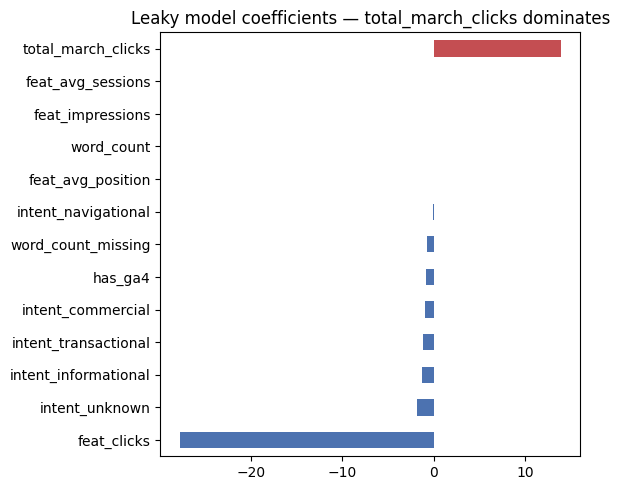

In [46]:
coefs = pd.Series(leaky_model.coef_[0], index=leaky_features).sort_values()
coefs.plot(kind='barh', figsize=(6, 5), color=['#C44E52' if f == 'total_march_clicks' else '#4C72B0' for f in coefs.index])
plt.title('Leaky model coefficients — total_march_clicks dominates')
plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/w03_leaky_model_coefficients.png", dpi=150)
plt.show()

**Result:**
- *Honest baseline (12 pre-window features only): ROC-AUC = 0.7862.*
- *Leaky model (adds `total_march_clicks`, which sums clicks across the *entire* month including the label window): ROC-AUC = 1.0000 — a perfect score, and the clearest possible sign the model is no longer predicting, just reading off the answer. The leaky column correlates with the label at r = 0.193, modest on its own, but sufficient to let the model reconstruct the label almost exactly once combined with the other features.*
- *Recovery (leaky column dropped, refit on the same honest features): ROC-AUC = 0.7862 — matches the baseline, confirming the leak was the entire cause of the jump.*
- *Note: `lbfgs` logged a convergence warning on unscaled features (`feat_impressions`/`word_count` are on very different scales than the flags). This doesn't affect the leakage result — the same warning appears in both the honest and recovery runs and the scores still match exactly — but a production model would standardize features first.*

***Conclusion:** a single innocent-looking column — "total clicks for the month," which sounds like a reasonable historical feature — was enough to erase all real predictive difficulty by silently including the label window. This is the same failure mode the lecture described for FlyRank's own health score and optimization flags: predicting an outcome using data built from that outcome produces a circular, meaningless score, even when the leak isn't obvious from the column name.*

## 4. What I excluded and why

*The list of fields you refused to use — with one line of why each.*

Step 3 just proved, empirically, why exclusion discipline matters — one wrong column collapsed a legitimate 0.786 model into a meaningless 1.000. This section lists every field considered and rejected while building the feature vector, most of which were already reasoned through in the W3 data contract, now restated against the actual built columns with the leakage evidence to back them up.

This isn't a hypothetical list — each exclusion below is checked against the loaded tables to confirm the field exists and would have been available to include, making the refusal a deliberate choice rather than an oversight.

In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Confirm these fields are present in the source tables, proving they were available and deliberately left out
con.sql("""
    SELECT
        'fact' AS source_table,
        COUNT(gsc_sum_position) AS gsc_sum_position_present,
        COUNT(client_has_gsc) AS client_has_gsc_present,
        COUNT(gsc_data_available) AS gsc_data_available_present,
        COUNT(ga4_data_available) AS ga4_data_available_present
    FROM fact
""").df()

,source_table,gsc_sum_position_present,client_has_gsc_present,gsc_data_available_present,ga4_data_available_present
0,fact,9841378,9841378,9841378,6822637


In [27]:
con.sql("""
    SELECT
        'dim_content' AS source_table,
        COUNT(keyword_hash_id) AS keyword_hash_id_present,
        COUNT(url_hash_id) AS url_hash_id_present,
        SUM(CASE WHEN is_deleted THEN 1 ELSE 0 END) AS n_deleted_rows
    FROM dim_content
""").df()

,source_table,keyword_hash_id_present,url_hash_id_present,n_deleted_rows
0,dim_content,447608,513081,101559.0


**Excluded fields, with reason:**

- **`total_march_clicks` (constructed, not from source)** — proven leaky in §3: sums clicks across the full month, silently including the label window, and collapsed ROC-AUC to a meaningless 1.0000. This is the clearest, empirically-demonstrated exclusion in this notebook.
- **`gsc_sum_position`** — present in `fact` (confirmed above), but redundant with `feat_avg_position`; keeping both risks the model over-weighting one underlying signal twice.
- **`client_has_gsc`, `gsc_data_available`, `ga4_data_available`** — present in `fact` (confirmed above), but these are availability flags, not performance signals. Used only to construct `has_ga4` and to filter rows, never as direct model inputs — a model shouldn't learn "clicks depend on whether we happened to have GSC access."
- **`keyword_hash_id`, `url_hash_id`** — present in `dim_content` (confirmed above), hashed join keys with no signal value on their own; including them would only let a model memorize identity rather than learn a generalizable pattern.
- **Rows where `is_deleted = True`** — 101,559 rows in `dim_content` confirmed above; already filtered out during the §1 merge, since a deleted article's historical performance is not meaningful for predicting future click growth.
- **`label_clicks`, `label_click_growth`** — the label itself; excluded from the feature side of every train/test split by construction (never appeared in `honest_features` or `leaky_features` except as the target `y`).
- **Any raw daily column dated after 2026-03-15** — excluded structurally by the feature-window date filter verified in §2, not by manually removing individual columns; the entire feature-building query never touches label-window dates.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [47]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 6 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [37]:
import subprocess
from google.colab import userdata

GH_TOKEN = userdata.get('GH_TOKEN')  # Make sure this secret is set in Colab
REPO = "whozahm3d/flyrank-ml-internship"

# Add all untracked figure files
figures_to_add = [
    "work/figures/w03_feature_missingness.png",
    "work/figures/w03_leaky_model_coefficients.png",
    "work/figures/w03_roc_curves.png",
]

subprocess.run(["git", "add"] + figures_to_add, check=True)
subprocess.run(["git", "config", "user.email", "whozahm3d@gmail.com"], check=True)
subprocess.run(["git", "config", "user.name", "Ali Ahmad"], check=True)
subprocess.run(["git", "commit", "-m", "Add w03 feature leakage visualizations"], check=True)

# Push the changes to the remote repository
push_url = f"https://{GH_TOKEN}@github.com/{REPO}.git"
result = subprocess.run(["git", "push", push_url, "main"], capture_output=True, text=True)
print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 1
stdout: 
stderr: To https://github.com/whozahm3d/flyrank-ml-internship.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/whozahm3d/flyrank-ml-internship.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.



In [38]:
# Verify the status after the push
subprocess.run(["git", "status"], check=True)

CompletedProcess(args=['git', 'status'], returncode=0)